<div style="display: flex; align-items: center; width: 100%;">  
  <div style="display: flex; flex-direction: column; align-items: center; justify-content: center; width: 100px; margin-right: 0px;">    
    <a href="https://risklab.ai" style="border: 0; line-height: 0.5;">
      <img src="../../Utils/risklab_ai.gif" width="60px" style="border: 0; margin-bottom:-10px; vertical-align: middle;"/>
    </a>
  </div>  
  <div style="flex-grow: 1;">
    <h1 style="margin: 0; margin-left:0; font-weight: bold; text-align: left; font-size: 38px;">
      Triple-Barrier Labeling &amp; Meta-Labeling
    </h1>
  </div>  
</div>

Fixed-horizon labels ("up or down after N days?") ignore *how* the path got
there and the risk taken along the way. De Prado's **triple-barrier method**
labels each event by which of three barriers it hits first: an upper
(profit-take), a lower (stop-loss), or a vertical (time) barrier. The barrier
widths scale with **volatility**, and events are sampled with a **CUSUM filter**
so we only label when something meaningful has moved.

We run the full pipeline on the S&P 500 from FRED:

CUSUM event sampling → volatility-scaled barriers → triple-barrier labels →
meta-labels.

Reference: López de Prado, *Advances in Financial Machine Learning*, Ch. 3.

## 1. Price series (FRED)

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, "..", ".."))   # the pinned notebook environment

using RiskLabAI
using RiskLabAI.Data: symmetric_cusum_filter, daily_volatility_with_log_returns,
    vertical_barrier, meta_events, meta_labeling, find_trend_using_trend_scanning
using FredData, DataFrames, Statistics, Dates, Plots
gr()

  Activating project at `C:\arian\risklabai\Notebooks.jl`


Plots.GRBackend()

In [2]:
fred = Fred()
series = get_data(fred, "SP500")
df = dropmissing(series.data, :value)
dates = DateTime.(df.date)
close = Float64.(df.value); keep = .!isnan.(close); close = close[keep]; dates = dates[keep]

println("$(length(close)) observations, $(dates[1]) to $(dates[end])")

API key loaded.
2514 observations, 2016-06-20T00:00:00 to 2026-06-18T00:00:00


## 2. Sample events with a CUSUM filter

The symmetric CUSUM filter fires when the cumulative up- or down-move exceeds a
threshold — flagging meaningful directional runs while ignoring noise. We size
the threshold from the data (a multiple of the average daily move).

In [3]:
threshold = 3.0 * mean(abs.(diff(close)))
events = symmetric_cusum_filter(dates, close, threshold)
println("threshold = $(round(threshold; digits = 2)) → $(length(events)) events")

threshold = 87.33 → 398 events


## 3. Volatility-scaled barriers

Barrier widths are set by a rolling estimate of daily volatility (so each label
reflects the same *risk-adjusted* move), and a 5-day **vertical** barrier caps
the holding period.

In [4]:
vol = daily_volatility_with_log_returns(dates, close; span = 50)
target = Dict(vol.index[i] => vol.volatility[i]
              for i in eachindex(vol.index) if !isnan(vol.volatility[i]))
events = filter(e -> haskey(target, e), events)   # keep events with a volatility estimate

vb = vertical_barrier(dates, events, 5)
vertical = Dict(vb.event[i] => vb.barrier[i] for i in eachindex(vb.event))
println("usable events: $(length(events))   |   with a 5-day vertical barrier: $(length(vb.event))")

usable events: 398   |   with a 5-day vertical barrier: 396


## 4. Triple-barrier labels + meta-labeling

`meta_events` finds, for each event, which barrier is touched first (profit-take,
stop-loss, or time). `meta_labeling` turns the touched events into a label
(`+1` / `-1`) and the realized return — the targets a primary model learns, and
the foundation for a meta-model that decides *whether to act*.

labeled events: 397   |   +1: 230   -1: 167   |   mean return: 0.0013


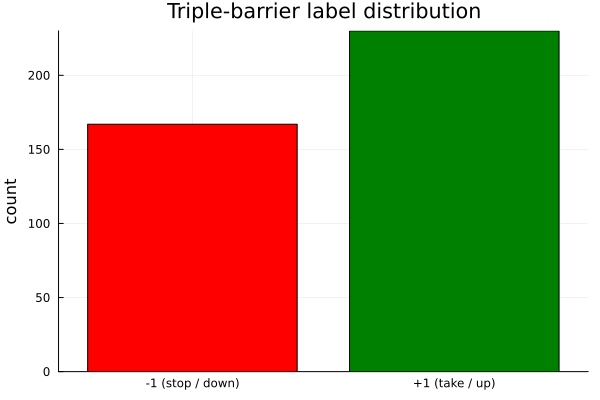

In [5]:
ev = meta_events(dates, close, events, (1.0, 1.0), target, 0.0; vertical_barriers = vertical)
ml = meta_labeling(ev, dates, close)

n_up   = count(==(1.0), ml.label)
n_down = count(==(-1.0), ml.label)
println("labeled events: $(length(ml.label))   |   +1: $n_up   -1: $n_down   |   ",
        "mean return: $(round(mean(ml.ret); digits = 4))")
bar(["-1 (stop / down)", "+1 (take / up)"], [n_down, n_up];
    legend = false, ylabel = "count", c = [:red, :green],
    title = "Triple-barrier label distribution")

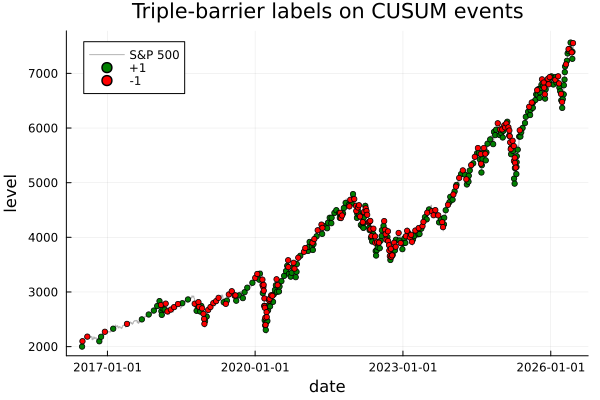

In [6]:
# Mark the labeled events on the price path.
price_of = Dict(dates[i] => close[i] for i in eachindex(dates))
valid = .!ismissing.(ev.end_time)
labeled = ev.event_start[valid]                  # aligns with ml.label
up_events   = labeled[ml.label .== 1.0]
down_events = labeled[ml.label .== -1.0]

plot(dates, close; lw = 1, c = :gray, alpha = 0.6, label = "S&P 500", legend = :topleft,
     xlabel = "date", ylabel = "level", title = "Triple-barrier labels on CUSUM events")
scatter!(up_events, [price_of[t] for t in up_events]; c = :green, ms = 3, label = "+1")
scatter!(down_events, [price_of[t] for t in down_events]; c = :red, ms = 3, label = "-1")

## 5. Bonus: trend-scanning labels

An alternative to the triple barrier: **trend scanning** labels each event by the
sign and strength (t-value) of the best-fitting local trend over horizons in a
given range — no barriers or volatility targets required.

In [7]:
trend = find_trend_using_trend_scanning(events, dates, close, (5, 20))
println("trend-scanning labels — up: $(count(==(1.0), trend.trend)), ",
        "down: $(count(==(-1.0), trend.trend)), flat: $(count(==(0.0), trend.trend))")
first(trend, 5)

trend-scanning labels — up: 252, down: 140, flat: 0


Row,event_start,end_time,t_value,trend
,DateTime,DateTime,Float64,Float64
1,2016-06-27T00:00:00,2016-07-25T00:00:00,10.1956,1.0
2,2016-06-30T00:00:00,2016-07-28T00:00:00,9.66868,1.0
3,2016-08-05T00:00:00,2016-09-01T00:00:00,-2.38201,-1.0
4,2016-11-02T00:00:00,2016-11-30T00:00:00,10.5572,1.0
5,2016-11-15T00:00:00,2016-12-13T00:00:00,7.08337,1.0


## Takeaways

- **CUSUM** sampling labels only meaningful moves, avoiding the redundancy of
  fixed-interval sampling.
- The **triple-barrier** method produces path-aware, risk-adjusted labels (which
  of profit-take / stop-loss / time is hit first).
- **Meta-labeling** sits on top: a primary model picks the side, a meta-model
  decides whether to take the bet — improving precision.
- **Trend scanning** is a barrier-free alternative based on local trend strength.

All from `RiskLabAI.Data`: `symmetric_cusum_filter`,
`daily_volatility_with_log_returns`, `vertical_barrier`, `meta_events`,
`meta_labeling`, `find_trend_using_trend_scanning`.